In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = datasets.FashionMNIST(root="./data", train=True,  download=True, transform=transform)
val_dataset   = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=128, shuffle=False)

In [6]:
model = nn.Sequential(
    nn.Flatten(),                          

    nn.Linear(784, 256),                
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(p=0.3),

    nn.Linear(256, 128),                 
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.3),

    nn.Linear(128, 64),         
    nn.BatchNorm1d(64),
    nn.ReLU(),

    nn.Linear(64, 10)                
)

model = model.to(device)
print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU()
  (4): Dropout(p=0.3, inplace=False)
  (5): Linear(in_features=256, out_features=128, bias=True)
  (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): ReLU()
  (8): Dropout(p=0.3, inplace=False)
  (9): Linear(in_features=128, out_features=64, bias=True)
  (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU()
  (12): Linear(in_features=64, out_features=10, bias=True)
)


In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 15
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

In [8]:
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, epochs + 1):

    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X.size(0)
        correct      += (logits.argmax(1) == y).sum().item()
        total        += X.size(0)

    train_losses.append(running_loss / total)
    train_accs.append(correct / total)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            val_loss    += criterion(logits, y).item() * X.size(0)
            val_correct += (logits.argmax(1) == y).sum().item()
            val_total   += X.size(0)

    val_losses.append(val_loss / val_total)
    val_accs.append(val_correct / val_total)

    scheduler.step()

    print(f"Epoch {epoch:02d}/{epochs} | "
          f"Train Loss: {train_losses[-1]:.4f}  Acc: {train_accs[-1]:.4f} | "
          f"Val Loss: {val_losses[-1]:.4f}  Acc: {val_accs[-1]:.4f}")

Epoch 01/15 | Train Loss: 0.5880  Acc: 0.8114 | Val Loss: 0.4071  Acc: 0.8523
Epoch 02/15 | Train Loss: 0.4039  Acc: 0.8540 | Val Loss: 0.3661  Acc: 0.8685
Epoch 03/15 | Train Loss: 0.3687  Acc: 0.8673 | Val Loss: 0.3652  Acc: 0.8689
Epoch 04/15 | Train Loss: 0.3445  Acc: 0.8749 | Val Loss: 0.3552  Acc: 0.8722
Epoch 05/15 | Train Loss: 0.3246  Acc: 0.8814 | Val Loss: 0.3313  Acc: 0.8806
Epoch 06/15 | Train Loss: 0.3089  Acc: 0.8865 | Val Loss: 0.3412  Acc: 0.8774
Epoch 07/15 | Train Loss: 0.3014  Acc: 0.8909 | Val Loss: 0.3165  Acc: 0.8863
Epoch 08/15 | Train Loss: 0.2855  Acc: 0.8943 | Val Loss: 0.3176  Acc: 0.8860
Epoch 09/15 | Train Loss: 0.2676  Acc: 0.9017 | Val Loss: 0.3009  Acc: 0.8919
Epoch 10/15 | Train Loss: 0.2568  Acc: 0.9062 | Val Loss: 0.3013  Acc: 0.8936
Epoch 11/15 | Train Loss: 0.2451  Acc: 0.9098 | Val Loss: 0.2982  Acc: 0.8920
Epoch 12/15 | Train Loss: 0.2323  Acc: 0.9151 | Val Loss: 0.2949  Acc: 0.8975
Epoch 13/15 | Train Loss: 0.2273  Acc: 0.9164 | Val Loss: 0.2915

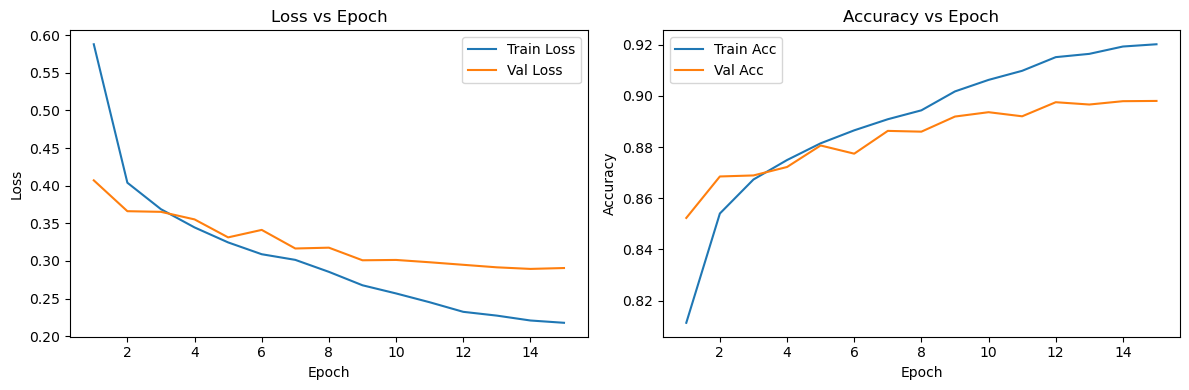

Best Val Accuracy: 0.8980  at epoch 15


In [9]:
ep = range(1, epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ep, train_losses, label="Train Loss")
ax1.plot(ep, val_losses,   label="Val Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Loss vs Epoch"); ax1.legend()

ax2.plot(ep, train_accs, label="Train Acc")
ax2.plot(ep, val_accs,   label="Val Acc")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy vs Epoch"); ax2.legend()

plt.tight_layout()
plt.show()

best_epoch = val_accs.index(max(val_accs)) + 1
print(f"Best Val Accuracy: {max(val_accs):.4f}  at epoch {best_epoch}")